# Measures of Frequency

While central tendency tells you *where* the middle is, and variability tells you *how spread out* the data is, **measures of frequency** simply answer the question: *How often does each value (or range of values) occur?*

Understanding frequency is usually the very first step in analyzing a dataset because it reveals the underlying "shape" of your data, which dictates what statistical tests you can run later.

## Core Frequency Concepts

Frequency can be expressed in a few different ways, depending on what you are trying to communicate:

* **Absolute Frequency (Count):** The raw, total number of times a specific value appears in your dataset. (e.g., "15 students scored exactly an 85% on the test.")
* **Relative Frequency (Proportion/Percentage):** The absolute frequency divided by the total number of observations. It tells you what *fraction* of the dataset a value represents. (e.g., "If there are 50 students total, the relative frequency of an 85% is 15/50, or 30%.")
* **Cumulative Frequency:** A running total of frequencies as you move through your ordered dataset. It adds the frequency of the current value to all preceding values. (e.g., "How many students scored an 85% *or lower*?")

---

## Visualizing Frequency

The most powerful way to understand frequency distributions is to visualize them.

### The Histogram

For continuous data (like age, height, income, or test scores), we use a **histogram**. Unlike a bar chart which separates distinct categories (like "Red", "Blue", "Green"), a histogram groups continuous numbers into continuous ranges, called **bins** or **intervals**.

{/* Reason: Visualizing a histogram helps distinguish it from a standard bar chart, which is a common point of confusion. */}

> **The "Binning" Problem:** The shape of a histogram can change drastically depending on how wide you make your bins. If your bins are too wide, you hide important details. If they are too narrow, the chart becomes a noisy mess.

---

## The Shape of Frequency: Skewness

When you plot frequencies, the resulting shape tells you immediately if your data is "normal" (a symmetric bell curve) or if it's biased toward one side.

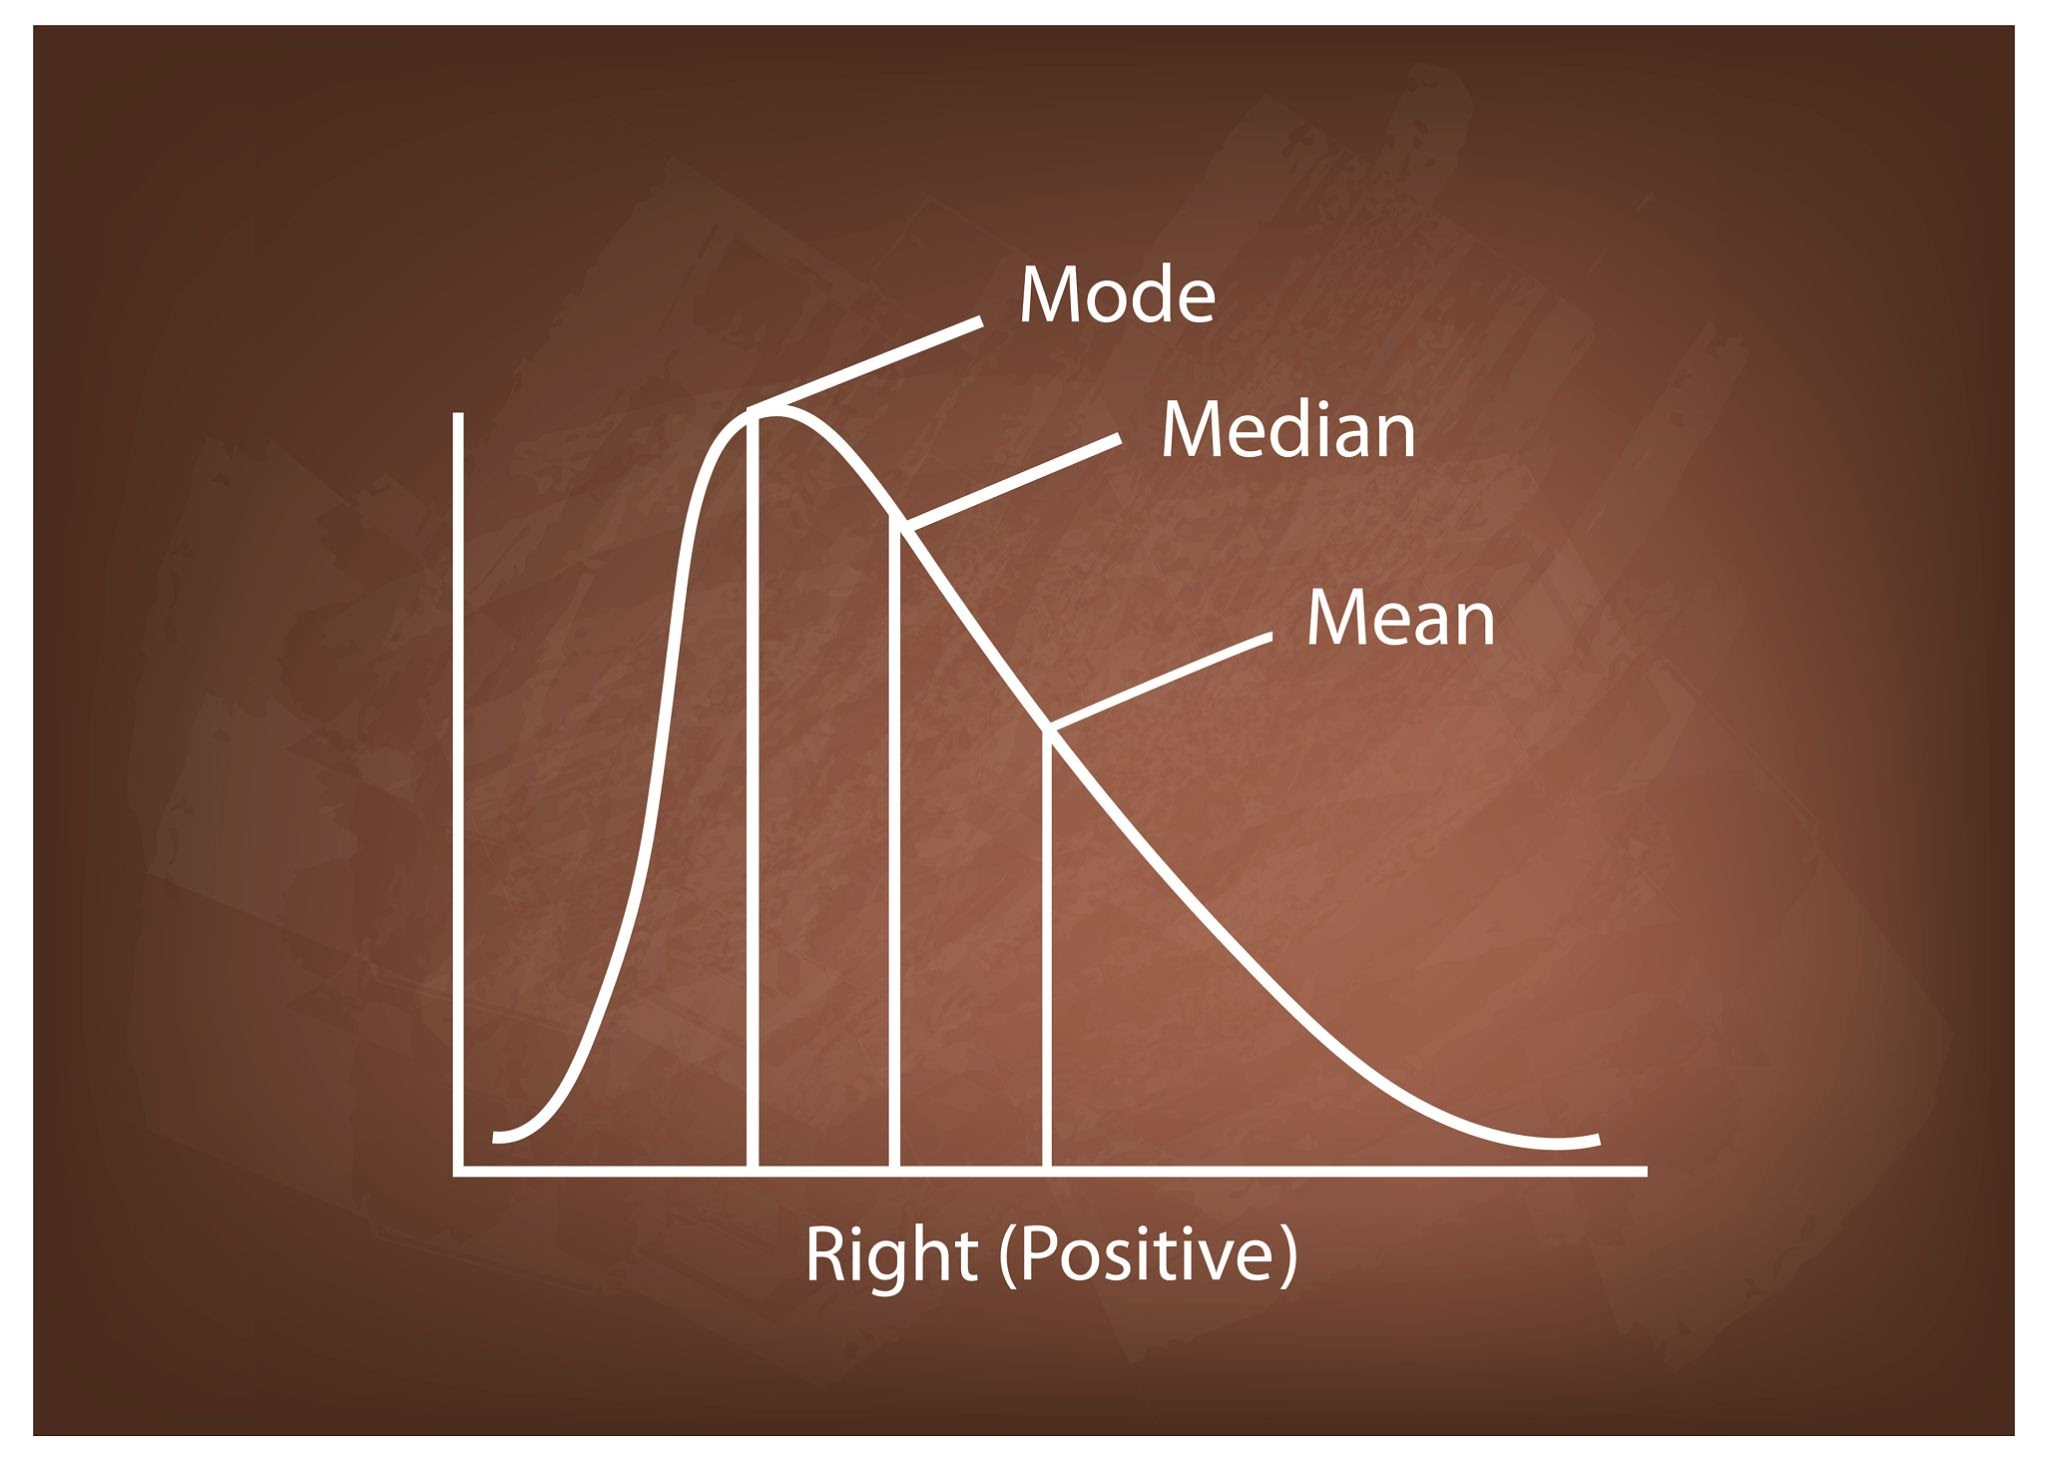

<center>Right (Positive) Skew. Source: Iamnee / Getty Images</center>

{/* Reason: A visual diagram comparing normal, left-skewed, and right-skewed distributions is essential for explaining how skewness shifts the mean away from the median. */}

* **Symmetric (Normal Distribution):** The left and right sides of the histogram mirror each other. The Mean, Median, and Mode all land in the exact same spot in the center.
* **Right-Skewed (Positive Skew):** The data has a long "tail" trailing off to the right (higher numbers). This happens when there's a hard floor on the left (e.g., you can't make less than $0), but no ceiling on the right (e.g., billionaires). *The Mean gets pulled to the right of the Median.*
* **Left-Skewed (Negative Skew):** The data has a long tail trailing off to the left. This happens on easy exams where most people score highly, but a few students score very low. *The Mean gets pulled to the left of the Median.*

This engine uses `scipy.stats` to generate a dataset where you can actually control the **skewness** (the shape) of the data, and adjust the **bin size** to see how it affects the frequency histogram and the cumulative frequency curve.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm, skew
import ipywidgets as widgets
from IPython.display import display

def update_frequency_plots(bins, skew_factor):
    """
    Generates data based on the chosen skew factor and redraws
    the histogram and cumulative frequency plots.
    """
    # 1. Generate sample data (1,000 points) with adjustable skew
    # skew_factor = 0 is normal. >0 is right-skewed. <0 is left-skewed.
    data = skewnorm.rvs(a=skew_factor, loc=50, scale=15, size=1000, random_state=42)

    # Calculate statistics to show how skew pulls the mean away from the median
    mean_val = np.mean(data)
    median_val = np.median(data)
    calculated_skew = skew(data)

    # Set up a side-by-side plot layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- PLOT 1: Absolute Frequency (Histogram) ---
    # We use density=False to show raw counts (Absolute Frequency)
    counts, edges, bars = ax1.hist(data, bins=bins, color='#3498db', edgecolor='black', alpha=0.7)

    # Add Mean and Median lines to show the effect of skewness
    ax1.axvline(mean_val, color='#e74c3c', linestyle='-', linewidth=3, label=f'Mean: {mean_val:.1f}')
    ax1.axvline(median_val, color='#2ecc71', linestyle='--', linewidth=3, label=f'Median: {median_val:.1f}')

    ax1.set_title(f"Absolute Frequency (Histogram)\nCalculated Skewness: {calculated_skew:.2f}", fontsize=14)
    ax1.set_xlabel("Values", fontsize=12)
    ax1.set_ylabel("Frequency (Count)", fontsize=12)
    ax1.legend()
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # --- PLOT 2: Cumulative Frequency ---
    # We use cumulative=True to show the running total
    ax2.hist(data, bins=bins, cumulative=True, color='#9b59b6', edgecolor='black', alpha=0.7)

    ax2.set_title("Cumulative Frequency Distribution", fontsize=14)
    ax2.set_xlabel("Values", fontsize=12)
    ax2.set_ylabel("Running Total (out of 1000)", fontsize=12)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    # Add a horizontal line at 500 (the 50th percentile / median)
    ax2.axhline(500, color='#2ecc71', linestyle='--', linewidth=2, alpha=0.8)
    ax2.text(min(data), 520, "50th Percentile (Median)", color='#27ae60', weight='bold')

    plt.tight_layout()
    plt.show()

# Create interactive sliders
print("Adjust the sliders below to explore frequency distributions:")

bin_slider = widgets.IntSlider(
    value=20, min=5, max=100, step=1,
    description='Bin Size:', continuous_update=False, layout=widgets.Layout(width='400px')
)

skew_slider = widgets.FloatSlider(
    value=0, min=-10.0, max=10.0, step=1.0,
    description='Skew Shape:', continuous_update=False, layout=widgets.Layout(width='400px')
)

# Bind the sliders to the plot function
widgets.interact(update_frequency_plots, bins=bin_slider, skew_factor=skew_slider);

Adjust the sliders below to explore frequency distributions:


interactive(children=(IntSlider(value=20, continuous_update=False, description='Bin Size:', layout=Layout(widt…

### What to Look For in the Interactive Dashboard

Once you run the cell, you will get two sliders. Here is how to use them to understand frequency:

1. **Play with the `Bin Size` slider:** Watch the **Histogram** on the left. If you drop the bins to `5`, the data looks like a few giant, unhelpful blocks (underfitting). If you push the bins up to `100`, the chart breaks down into tiny, jagged spikes that are hard to read (overfitting). You are visually finding the "Goldilocks" zone for absolute frequency.
2. **Play with the `Skew Shape` slider:**
    * Set it to `0` for a perfectly symmetrical, normal distribution. Notice how the Mean (Red) and Median (Green) sit exactly on top of each other.
    * Drag it all the way to `10` (Right/Positive Skew). Watch the tail stretch to the right, and notice how the red Mean line gets pulled to the right of the median.


3. **Look at the Cumulative Frequency (Right Plot):** Notice how it always forms an "S" curve (called an Ogive). It starts slow, climbs rapidly where the absolute frequency is highest (the "hump" of the histogram), and levels off at the top once it has counted all 1,000 data points.

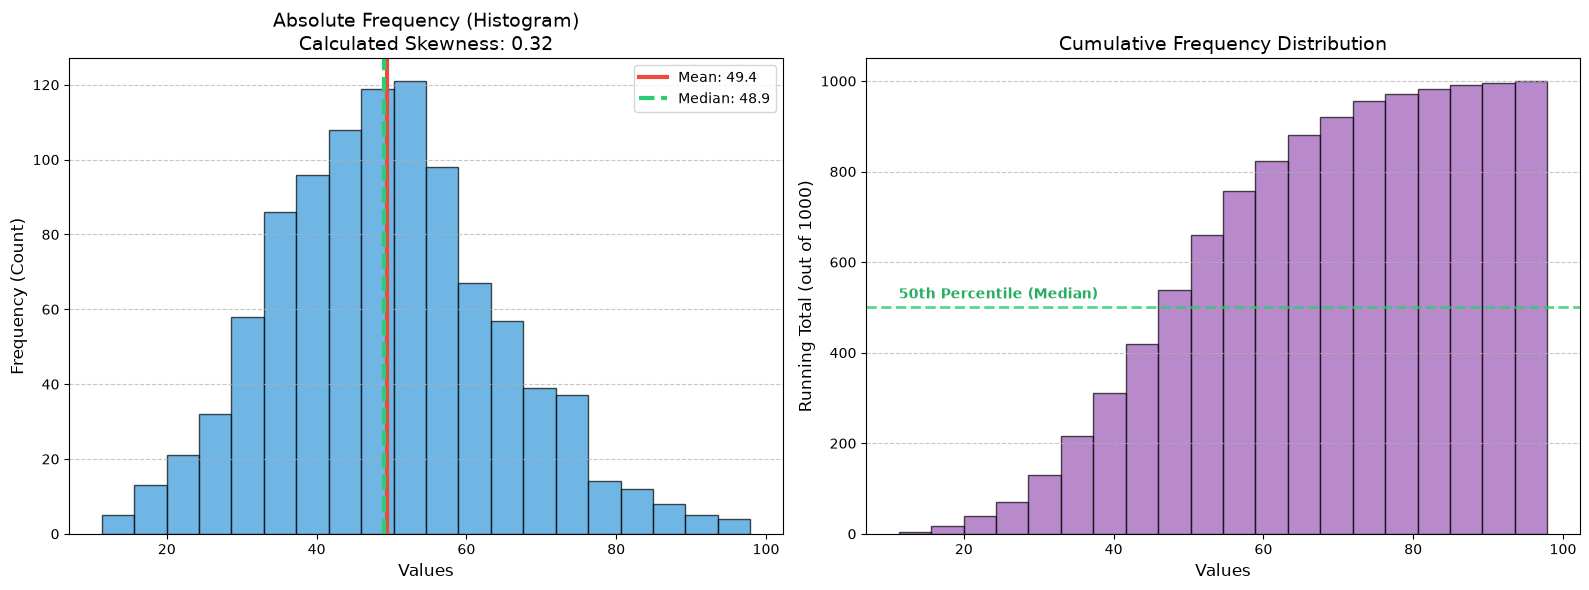

In [2]:
# --- static render for the published website ---
# The sliders above need a live Python kernel. This cell renders the same chart at
# the sliders' default values so the figure is always visible on the website.
update_frequency_plots(bins=20, skew_factor=0)
